Rule baseline predictions: 0    187
1    182
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 120, number of negative: 175
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2139
[LightGBM] [Info] Number of data points in the train set: 295, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.406780 -> initscore=-0.377294
[LightGBM] [Info] Start training from score -0.377294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

d:\Data\Documents\GitHub\mc-behavioral-cheat-detection\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


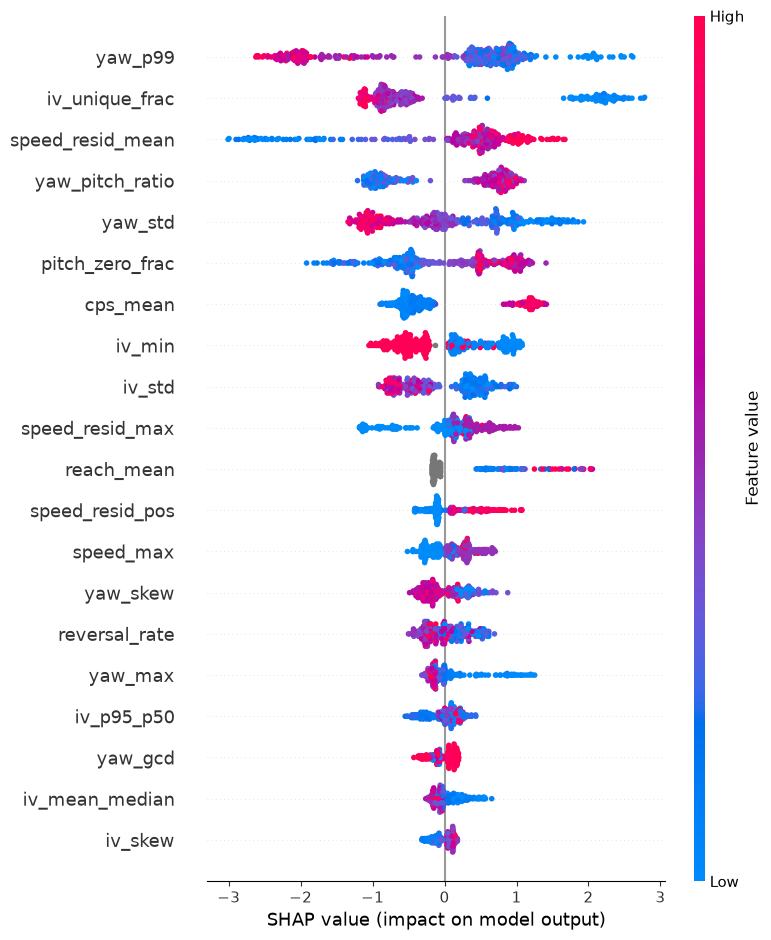

In [1]:
import sys
sys.path.append("../src")

from models import get_feature_cols, rule_baseline, train_cv, novelty_test, plot_calibration
import pandas as pd
import shap

X = pd.read_parquet("../data/processed/features.parquet")
features = get_feature_cols(X)

# Rule baseline first
rule_preds = rule_baseline(X)
print("Rule baseline predictions:", rule_preds.value_counts())

# Supervised model
oof, models = train_cv(X)

# SHAP: explain the first fold's model
explainer = shap.TreeExplainer(models[0])
shap_values = explainer.shap_values(X[features])
shap.summary_plot(shap_values, X[features])

In [4]:
import sys
sys.path.append("../src")

from models import get_feature_cols, rule_baseline, train_cv, novelty_test, plot_calibration
import pandas as pd
import shap

X = pd.read_parquet("../data/processed/features.parquet")
features = get_feature_cols(X)
print("Loaded:", X.shape)

Loaded: (369, 40)


In [5]:
print(sorted(X.columns.tolist()))

['air_const_y_frac', 'airborne_frac', 'cps_mean', 'fall_resid_max', 'fall_resid_std', 'hit_rate', 'is_cheat', 'iv_cv', 'iv_kurtosis', 'iv_mean_median', 'iv_min', 'iv_p95_p50', 'iv_skew', 'iv_std', 'iv_unique_frac', 'label', 'ping_mean', 'pitch_zero_frac', 'player', 'reach_max', 'reach_mean', 'reach_over_29', 'reach_over_30', 'reach_p95', 'reach_std', 'reversal_rate', 'session_id', 'snap_count', 'speed_max', 'speed_resid_max', 'speed_resid_mean', 'speed_resid_pos', 'window_id', 'yaw_gcd', 'yaw_kurtosis', 'yaw_max', 'yaw_p99', 'yaw_pitch_ratio', 'yaw_skew', 'yaw_std']


In [6]:
print(X.yaw_gcd.describe())
print(X.iv_cv.describe())
print(X.groupby("label").yaw_gcd.describe())

count    369.000000
mean       0.037833
std        0.005589
min        0.020200
25%        0.039200
50%        0.040000
75%        0.040300
max        0.041600
Name: yaw_gcd, dtype: float64
count    367.000000
mean       0.601293
std        0.342893
min        0.128169
25%        0.319669
50%        0.506878
75%        0.829690
max        1.844619
Name: iv_cv, dtype: float64
             count      mean       std     min       25%       50%     75%  \
label                                                                        
AUTOCLICKER   41.0  0.039259  0.002493  0.0252  0.039000  0.039950  0.0402   
KILLAURA      44.0  0.038665  0.004128  0.0209  0.039600  0.039925  0.0402   
LEGIT        226.0  0.037104  0.006524  0.0202  0.038888  0.040075  0.0403   
REACH         58.0  0.039036  0.003296  0.0218  0.039500  0.040000  0.0402   

                max  
label                
AUTOCLICKER  0.0416  
KILLAURA     0.0406  
LEGIT        0.0414  
REACH        0.0405  


In [7]:
print(X["reach_mean"].isna().sum(), "of", len(X), "windows missing reach data")
print(X.groupby("label")[["reach_p95"]].describe())

283 of 369 windows missing reach data
            reach_p95                                                    \
                count      mean       std       min       25%       50%   
label                                                                     
AUTOCLICKER      20.0  2.925470  0.359945  2.337949  2.667352  2.904609   
KILLAURA          0.0       NaN       NaN       NaN       NaN       NaN   
LEGIT            51.0  3.165934  0.236901  2.643000  3.030888  3.163279   
REACH            15.0  5.281319  0.277767  4.720173  5.102531  5.393489   

                                 
                  75%       max  
label                            
AUTOCLICKER  3.097126  3.754163  
KILLAURA          NaN       NaN  
LEGIT        3.296667  3.659398  
REACH        5.424871  5.582502  


In [8]:
oof, models = train_cv(X)

[LightGBM] [Info] Number of positive: 120, number of negative: 175
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2139
[LightGBM] [Info] Number of data points in the train set: 295, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.406780 -> initscore=-0.377294
[LightGBM] [Info] Start training from score -0.377294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes